
0: 1024x576 6 titles, 11 plain texts, 1 abandon, 2 figures, 1 figure_caption, 6 isolate_formulas, 3 formula_captions, 9415.2ms
Speed: 30.8ms preprocess, 9415.2ms inference, 3.7ms postprocess per image at shape (1, 3, 1024, 576)
Zones détectées : 30


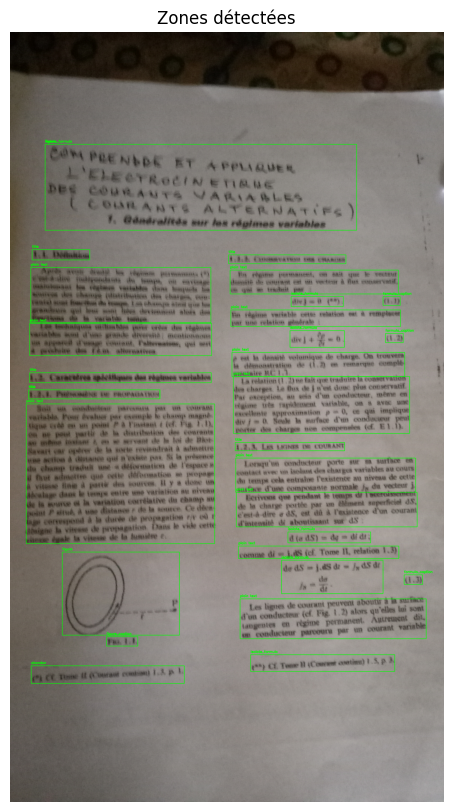

In [12]:
import sys
sys.path.append("..")  # remonte au dossier OCRFlow
from detector import DocLayoutDetector
import cv2
from matplotlib import pyplot as plt

# Init

model_path = "../doclayout_yolo_docstructbench_imgsz1280_2501.pt"
image_path = "../data/raw/IMG_20190922_171638.jpg"

# --- Init du détecteur ---
detector = DocLayoutDetector(model_path, confidence=0.3)

# Détection
image = detector.load_image(image_path)
zones = detector.detect_layout(image)

print(f"Zones détectées : {len(zones)}")
# Affichage avec rectangles
for zone in zones:
    x1, y1, x2, y2 = zone["bbox"]
    cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(image, zone["type"], (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

# Convertir BGR → RGB pour afficher correctement avec matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Zones détectées")
plt.show()